In [1]:
import numpy as np
import pandas as pd
import os


/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_log_error
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer

import lightgbm as lgb
import xgboost as xgb

pd.set_option('display.max_columns', 30)
sns.set_style('whitegrid')
RANDOM_STATE = 42

# USE_FULL_DATA=False → 20k train rows (~10 min). True → full 138k (~1+ hr)
USE_FULL_DATA = True
SKIP_GRIDSEARCH = True
SAMPLE_SIZE = 20000
N_FOLDS = 3


In [3]:
import os

def find_data_paths():
    from pathlib import Path
    candidates = []
    if os.path.exists("/kaggle/input"):
        for root, _, files in os.walk("/kaggle/input"):
            if "train.csv" in files and "test.csv" in files:
                candidates.append(Path(root))
    candidates.extend([
        Path("../data"),
        Path("data"),
        Path("."),
    ])
    for root in candidates:
        if (root / "train.csv").exists() and (root / "test.csv").exists():
            sample_path = root / "sample_submission.csv"
            return (
                str(root / "train.csv"),
                str(root / "test.csv"),
                str(sample_path) if sample_path.exists() else "sample_submission.csv",
            )
    raise FileNotFoundError("train.csv / test.csv not found locally or under /kaggle/input")


TRAIN_PATH, TEST_PATH, SAMPLE_SUB_PATH = find_data_paths()
SUB_PATH = 'submission.csv'

print(f'TRAIN_PATH: {TRAIN_PATH}')
print(f'TEST_PATH: {TEST_PATH}')
print(f'SAMPLE_SUB_PATH: {SAMPLE_SUB_PATH}')

ss = pd.read_csv(SAMPLE_SUB_PATH)

# Use TRAIN_PATH / TEST_PATH (file paths), NOT train / test (DataFrames)
if USE_FULL_DATA:
    train = pd.read_csv(TRAIN_PATH)
    test = pd.read_csv(TEST_PATH)
else:
    train = pd.read_csv(TRAIN_PATH, nrows=SAMPLE_SIZE)
    test = pd.read_csv(TEST_PATH, nrows=3000)

print(f'Train: {train.shape} | Test: {test.shape}')
train.head()


TRAIN_PATH: /kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
TEST_PATH: /kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv
SAMPLE_SUB_PATH: /kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
Train: (138701, 50) | Test: (15000, 49)


,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,Spec_FullDescriptor,Spec_BaseClass,Spec_SubClass,Spec_ReleaseSeries,Spec_VariantModifier,...,col14,col15,col16,col18,col19,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,950FII,950,F,II,NaN,...,NaN,23.5,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,310G,310,G,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,790ELC,790,E,NaN,LC,...,NaN,NaN,None or Unspecified,NaN,NaN,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,416D,416,D,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,430HAG,430,HAG,NaN,NaN,...,NaN,NaN,Manual,NaN,NaN,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


Target statistics:


count    138701.000000
mean      41521.874047
std       26361.125948
min        7500.000000
25%       20500.000000
50%       35000.000000
75%       57000.000000
max      142000.000000
Name: TargetValue, dtype: float64

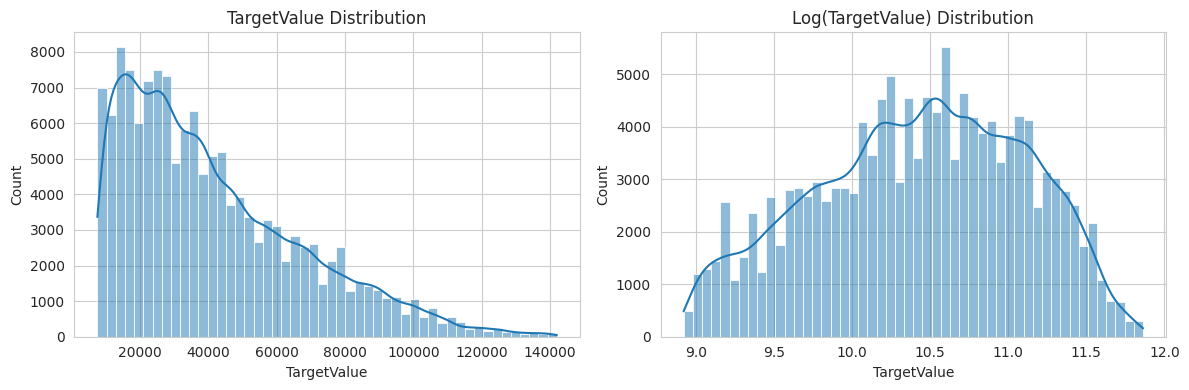

In [4]:
print('Target statistics:')
display(train['TargetValue'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train['TargetValue'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('TargetValue Distribution')
sns.histplot(np.log1p(train['TargetValue']), bins=50, kde=True, ax=axes[1])
axes[1].set_title('Log(TargetValue) Distribution')
plt.tight_layout()
plt.show()


Top missing columns (%):
col19    99.952416
col18    99.952416
col5     92.515555
col4     92.515555
col27    89.214930
col28    89.214930
col29    86.393753
col30    86.393753
col13    83.125572
col14    83.125572
col7     83.125572
col6     83.125572
col9     83.125572
col8     83.125572
col11    83.125572
dtype: float64


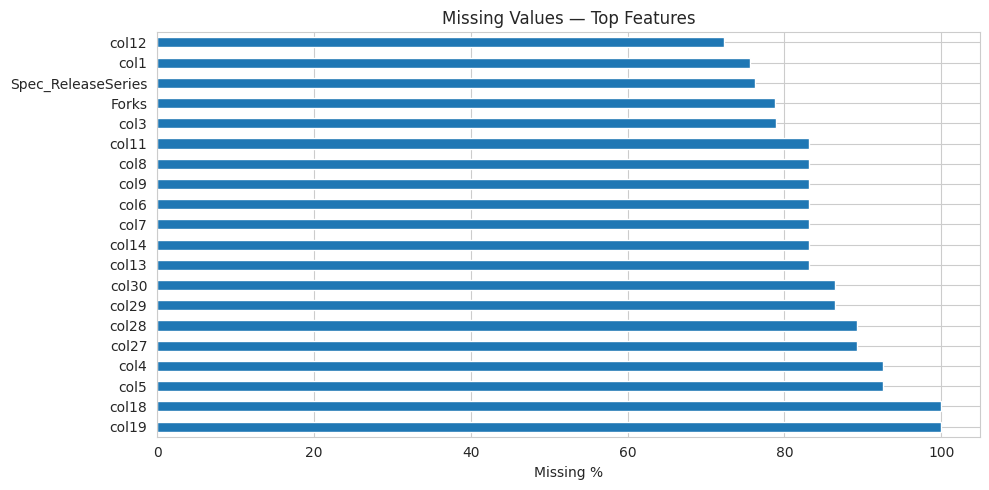

In [5]:
miss = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
print('Top missing columns (%):')
print(miss.head(15))

fig, ax = plt.subplots(figsize=(10, 5))
miss[miss > 0].head(20).plot(kind='barh', ax=ax)
ax.set_xlabel('Missing %')
ax.set_title('Missing Values — Top Features')
plt.tight_layout()
plt.show()


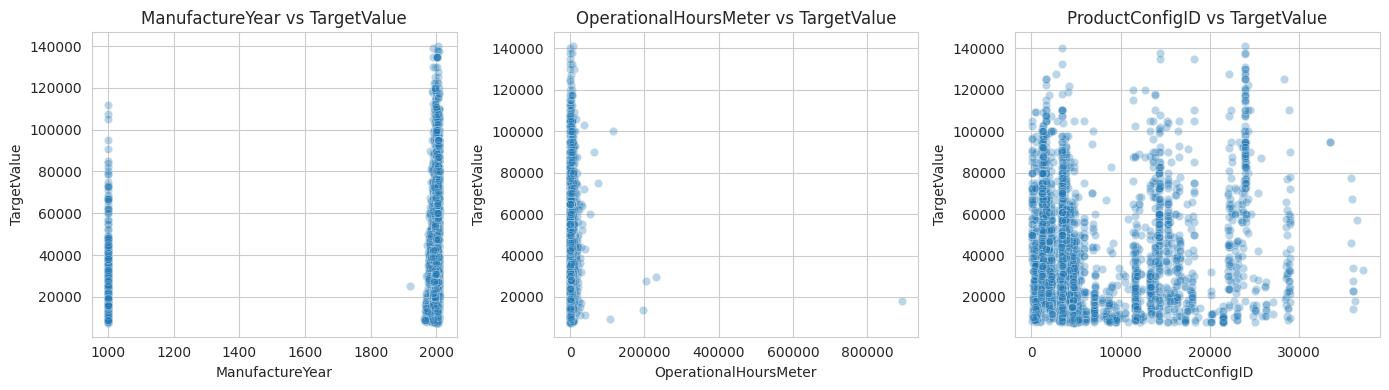

In [6]:
num_cols = ['ManufactureYear', 'OperationalHoursMeter', 'ProductConfigID']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, num_cols):
    sns.scatterplot(data=train.sample(min(3000, len(train))), x=col, y='TargetValue', alpha=0.3, ax=ax)
    ax.set_title(f'{col} vs TargetValue')
plt.tight_layout()
plt.show()


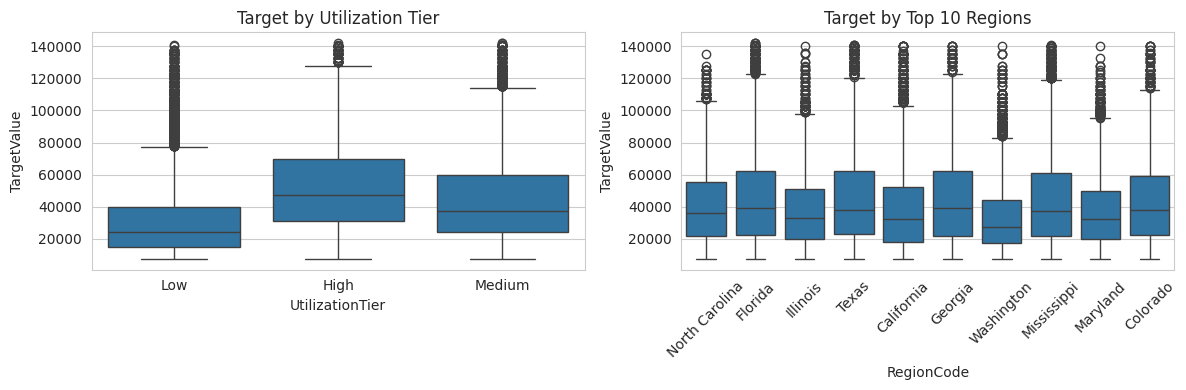

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=train, x='UtilizationTier', y='TargetValue', ax=axes[0])
axes[0].set_title('Target by Utilization Tier')
top_regions = train['RegionCode'].value_counts().head(10).index
sns.boxplot(data=train[train['RegionCode'].isin(top_regions)], x='RegionCode', y='TargetValue', ax=axes[1])
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_title('Target by Top 10 Regions')
plt.tight_layout()
plt.show()


Mean TargetValue by Inventory Group:


,mean,count
InventoryGroupCategory,,
TEX,39281.266299,71018
MG,47722.283828,23405
WL,46468.955331,18872
TTT,48733.741239,14959
BL,23649.794721,10381
SSL,15602.272727,66


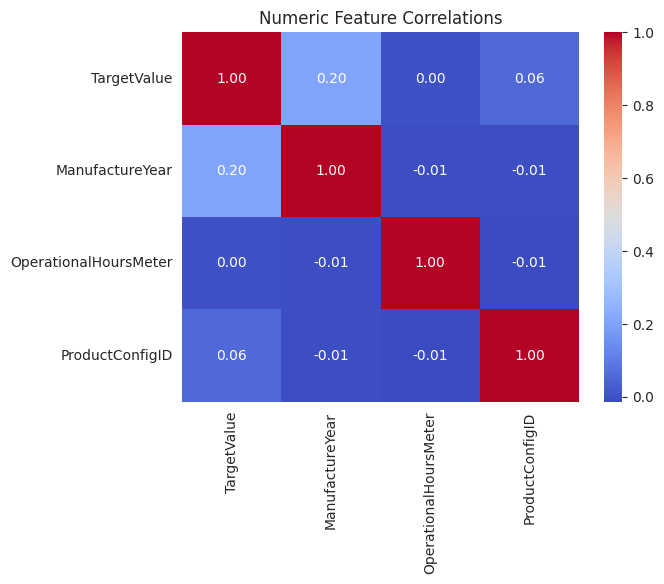

In [8]:
top_cat = train.groupby('InventoryGroupCategory')['TargetValue'].agg(['mean', 'count']).sort_values('count', ascending=False)
print('Mean TargetValue by Inventory Group:')
display(top_cat)

corr_num = train[['TargetValue', 'ManufactureYear', 'OperationalHoursMeter', 'ProductConfigID']].corr()
sns.heatmap(corr_num, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Numeric Feature Correlations')
plt.show()


In [9]:
TE_COLS = [
    'RegionCode', 'InventoryGroupCategory', 'FunctionalClassification',
    'Spec_BaseClass', 'ProductConfigID', 'InventoryGroupDescription',
    'VendorPartnerID', 'Spec_SubClass', 'DataOriginCode'
]
DROP_COLS = ['TransactionID', 'TargetValue', 'TransactionDate', 'Spec_FullDescriptor', 'AssetID']
MISS_THRESH = 0.85
SMOOTHING = 30


def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))


def add_date_features(df):
    out = df.copy()
    out['TransactionDate'] = pd.to_datetime(out['TransactionDate'], errors='coerce')
    out['TxYear'] = out['TransactionDate'].dt.year
    out['TxMonth'] = out['TransactionDate'].dt.month
    out['TxQuarter'] = out['TransactionDate'].dt.quarter
    out['AssetAge'] = (out['TxYear'] - out['ManufactureYear']).clip(0, 50)
    hours = pd.to_numeric(out['OperationalHoursMeter'], errors='coerce').fillna(0)
    out['LogHours'] = np.log1p(hours)
    out['HoursPerYear'] = hours / (out['AssetAge'] + 1)
    out['SqrtHours'] = np.sqrt(hours)
    util_map = {'Low': 0, 'Medium': 1, 'High': 2}
    out['UtilNum'] = out['UtilizationTier'].map(util_map).fillna(1)
    return out


def get_feature_lists(df):
    cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
    num_cols = [c for c in df.columns if c not in cat_cols]
    return cat_cols, num_cols


def fit_transform_features(train_df, valid_df=None, artifacts=None):
    train = add_date_features(train_df)
    is_train = valid_df is None
    valid = add_date_features(valid_df) if valid_df is not None else None

    if is_train:
        artifacts = {}
        miss = train.drop(columns=[c for c in DROP_COLS if c in train.columns], errors='ignore').isnull().mean()
        artifacts['keep_cols'] = miss[miss <= MISS_THRESH].index.tolist()
        log_y = np.log1p(train['TargetValue'].values)
        artifacts['global_mean'] = log_y.mean()
        artifacts['medians'] = {}
        artifacts['te_maps'] = {}
        artifacts['freq_maps'] = {}
        artifacts['cat_maps'] = {}

    keep_cols = artifacts['keep_cols']

    def process_single(df, fit=False, y_log=None):
        drop = [c for c in DROP_COLS if c in df.columns]
        X = df.drop(columns=drop, errors='ignore')
        X = X[[c for c in keep_cols if c in X.columns]]
        cat_cols, num_cols = get_feature_lists(X)

        if fit:
            artifacts['medians'] = {c: pd.to_numeric(X[c], errors='coerce').median() for c in num_cols}
            low_card = [c for c in cat_cols if X[c].fillna('Missing').astype(str).nunique() <= 20]
            artifacts['low_card'] = low_card
            for c in TE_COLS:
                if c not in X.columns:
                    continue
                s = X[c].fillna('Missing').astype(str)
                agg = pd.DataFrame({'k': s, 't': y_log}).groupby('k')['t'].agg(['mean', 'count'])
                agg['te'] = (agg['count'] * agg['mean'] + SMOOTHING * artifacts['global_mean']) / (agg['count'] + SMOOTHING)
                artifacts['te_maps'][c] = agg['te'].to_dict()
                artifacts['freq_maps'][c] = s.value_counts(normalize=True).to_dict()
            for c in low_card:
                vals = X[c].fillna('Missing').astype(str).unique()
                artifacts['cat_maps'][c] = {v: i for i, v in enumerate(vals)}

        for c in num_cols:
            X[c] = pd.to_numeric(X[c], errors='coerce').fillna(artifacts['medians'].get(c, 0))
        for c in cat_cols:
            X[c] = X[c].fillna('Missing').astype(str)

        gm = artifacts['global_mean']
        for c in TE_COLS:
            if c not in X.columns or c not in artifacts['te_maps']:
                continue
            s = X[c].astype(str)
            X[f'{c}_te'] = s.map(artifacts['te_maps'][c]).fillna(gm)
            X[f'{c}_freq'] = s.map(artifacts['freq_maps'][c]).fillna(0)

        drop_high = [c for c in cat_cols if c not in artifacts.get('low_card', [])]
        X = X.drop(columns=drop_high, errors='ignore')
        for c in artifacts.get('low_card', []):
            if c in X.columns:
                X[c] = X[c].astype(str).map(artifacts['cat_maps'].get(c, {})).fillna(-1).astype(int)
        return X

    X_train = process_single(train, fit=True, y_log=np.log1p(train['TargetValue'].values))
    if valid is not None:
        X_valid = process_single(valid, fit=False)
        for c in X_train.columns:
            if c not in X_valid.columns:
                X_valid[c] = 0
        X_valid = X_valid[X_train.columns]
        return X_train, X_valid, artifacts
    return X_train, artifacts


def transform_test(test_df, artifacts):
    test = add_date_features(test_df)
    keep_cols = artifacts['keep_cols']
    drop = [c for c in DROP_COLS if c in test.columns]
    X = test.drop(columns=drop, errors='ignore')
    X = X[[c for c in keep_cols if c in X.columns]]
    cat_cols, num_cols = get_feature_lists(X)
    for c in num_cols:
        X[c] = pd.to_numeric(X[c], errors='coerce').fillna(artifacts['medians'].get(c, 0))
    for c in cat_cols:
        X[c] = X[c].fillna('Missing').astype(str)
    gm = artifacts['global_mean']
    for c in TE_COLS:
        if c not in X.columns or c not in artifacts['te_maps']:
            continue
        s = X[c].astype(str)
        X[f'{c}_te'] = s.map(artifacts['te_maps'][c]).fillna(gm)
        X[f'{c}_freq'] = s.map(artifacts['freq_maps'][c]).fillna(0)
    drop_high = [c for c in cat_cols if c not in artifacts.get('low_card', [])]
    X = X.drop(columns=drop_high, errors='ignore')
    for c in artifacts.get('low_card', []):
        if c in X.columns:
            X[c] = X[c].astype(str).map(artifacts['cat_maps'].get(c, {})).fillna(-1).astype(int)
    return X

X, artifacts = fit_transform_features(train)
y = train['TargetValue'].values
print(f'Processed features: {X.shape[1]} | Samples: {X.shape[0]}')
X.head()


Processed features: 55 | Samples: 138701


,ProductConfigID,DataOriginCode,ManufactureYear,OperationalHoursMeter,UtilizationTier,AssetScaleFactor,InventoryGroupCategory,InventoryGroupDescription,col1,CabinType,Forks,col3,DrivetrainType,col6,col7,...,InventoryGroupCategory_freq,FunctionalClassification_te,FunctionalClassification_freq,Spec_BaseClass_te,Spec_BaseClass_freq,ProductConfigID_te,ProductConfigID_freq,InventoryGroupDescription_te,InventoryGroupDescription_freq,VendorPartnerID_te,VendorPartnerID_freq,Spec_SubClass_te,Spec_SubClass_freq,DataOriginCode_te,DataOriginCode_freq
0,88,0,1997,4640.0,0,0,0,0,0,0,0,0,0,0,0,...,0.136062,10.712968,0.036943,10.893576,0.018637,10.866744,0.009034,10.585743,0.136062,10.402635,0.131441,10.466588,0.031889,10.399481,0.12191
1,4616,0,2005,508.0,0,1,1,1,1,1,0,1,1,0,0,...,0.074844,10.067002,0.054816,10.026663,0.017455,10.134750,0.009228,10.011990,0.074844,10.402635,0.131441,10.704096,0.125313,10.399481,0.12191
2,1948,0,1994,11540.0,1,2,2,2,0,2,1,2,0,0,0,...,0.512022,10.703881,0.080446,10.094679,0.005306,10.225280,0.002819,10.371046,0.512022,10.402635,0.131441,10.027550,0.039135,10.399481,0.12191
3,3550,0,2002,4883.0,1,1,1,1,1,1,0,1,2,0,0,...,0.074844,10.067002,0.054816,10.099471,0.010389,10.283414,0.003273,10.011990,0.074844,10.402635,0.131441,10.274800,0.042018,10.399481,0.12191
4,36014,0,2009,302.0,0,3,2,2,0,2,1,2,0,0,0,...,0.512022,9.530050,0.024254,10.137208,0.001954,10.186670,0.000144,10.371046,0.512022,10.402635,0.131441,10.125543,0.000281,10.399481,0.12191


In [10]:
def cv_evaluate(model, X, y, model_name, n_folds=N_FOLDS):
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    oof = np.zeros(len(y))
    log_y = np.log1p(y)
    fold_scores = []

    for fold, (tr_idx, va_idx) in enumerate(kf.split(X)):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        m = model

        if model_name in ('LightGBM', 'XGBoost'):
            m = type(model)(**model.get_params())
            if model_name == 'LightGBM':
                m.fit(X_tr, log_y[tr_idx], eval_set=[(X_va, log_y[va_idx])],
                      callbacks=[lgb.early_stopping(80, verbose=False)])
            else:
                m.fit(X_tr, log_y[tr_idx], eval_set=[(X_va, log_y[va_idx])], verbose=False)
        else:
            m.fit(X_tr, log_y[tr_idx])

        preds = np.expm1(m.predict(X_va))
        oof[va_idx] = preds
        fold_scores.append(rmsle(y[va_idx], preds))

    overall = rmsle(y, oof)
    return overall, oof, fold_scores


models = {
    'Ridge': Ridge(alpha=5.0),
    'RandomForest': RandomForestRegressor(
        n_estimators=200, max_depth=12, min_samples_leaf=5,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=1500, learning_rate=0.03, max_depth=10, num_leaves=128,
        subsample=0.8, colsample_bytree=0.5, min_child_samples=20,
        reg_alpha=0.3, reg_lambda=1.5, random_state=RANDOM_STATE, verbose=-1, n_jobs=-1
    ),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=1500, learning_rate=0.03, max_depth=8,
        subsample=0.8, colsample_bytree=0.5, reg_alpha=0.3, reg_lambda=1.5,
        random_state=RANDOM_STATE, verbosity=0, n_jobs=-1
    ),
}

results = {}
oof_preds = {}
for name, model in models.items():
    score, oof, folds = cv_evaluate(model, X, y, name)
    results[name] = score
    oof_preds[name] = oof
    print(f'{name:15s} | CV RMSLE: {score:.4f} | Folds: {[round(f, 4) for f in folds]}')

comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'CV_RMSLE': list(results.values())
}).sort_values('CV_RMSLE')
display(comparison)


Ridge           | CV RMSLE: 0.3194 | Folds: [np.float64(0.3193), np.float64(0.3199), np.float64(0.3189)]
RandomForest    | CV RMSLE: 0.2258 | Folds: [np.float64(0.2255), np.float64(0.2272), np.float64(0.2246)]
LightGBM        | CV RMSLE: 0.1982 | Folds: [np.float64(0.1969), np.float64(0.1993), np.float64(0.1985)]
XGBoost         | CV RMSLE: 0.1974 | Folds: [np.float64(0.1961), np.float64(0.1986), np.float64(0.1976)]


,Model,CV_RMSLE
3,XGBoost,0.197436
2,LightGBM,0.198220
1,RandomForest,0.225763
0,Ridge,0.319376


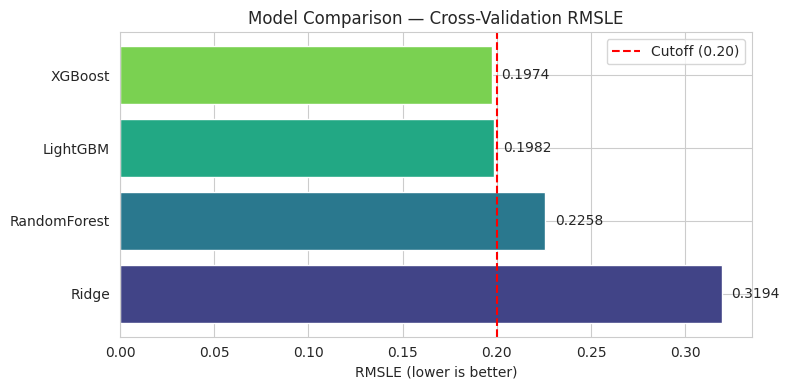

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = sns.color_palette('viridis', len(results))
bars = ax.barh(list(results.keys()), list(results.values()), color=colors)
ax.axvline(0.20, color='red', linestyle='--', label='Cutoff (0.20)')
ax.set_xlabel('RMSLE (lower is better)')
ax.set_title('Model Comparison — Cross-Validation RMSLE')
ax.legend()
for bar, val in zip(bars, results.values()):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center')
plt.tight_layout()
plt.show()


In [12]:
if SKIP_GRIDSEARCH:
    lgb_params = {
        'n_estimators': 2000, 'learning_rate': 0.03, 'max_depth': 10,
        'num_leaves': 128, 'subsample': 0.8, 'colsample_bytree': 0.5,
        'min_child_samples': 20, 'reg_alpha': 0.3, 'reg_lambda': 1.5
    }
    xgb_params = {
        'n_estimators': 2000, 'learning_rate': 0.03, 'max_depth': 8,
        'subsample': 0.8, 'colsample_bytree': 0.5,
        'reg_alpha': 0.3, 'reg_lambda': 1.5
    }
    print('Using pre-tuned parameters (GridSearchCV skipped)')
else:
    param_grid = {
        'num_leaves': [96, 128, 160],
        'max_depth': [8, 10, 12],
        'learning_rate': [0.02, 0.03],
        'subsample': [0.75, 0.85],
    }
    base = lgb.LGBMRegressor(
        n_estimators=1000, colsample_bytree=0.5, min_child_samples=20,
        reg_alpha=0.3, reg_lambda=1.5, random_state=RANDOM_STATE, verbose=-1, n_jobs=-1
    )
    gs = GridSearchCV(base, param_grid, scoring='neg_mean_squared_log_error', cv=3, n_jobs=-1)
    gs.fit(X, np.log1p(y))
    lgb_params = gs.best_params_
    lgb_params['n_estimators'] = 2000
    xgb_params = {
        'n_estimators': 2000, 'learning_rate': 0.03, 'max_depth': 8,
        'subsample': 0.8, 'colsample_bytree': 0.5,
        'reg_alpha': 0.3, 'reg_lambda': 1.5
    }
    print('Best params:', lgb_params)
    print(f'Best CV RMSLE: {np.sqrt(-gs.best_score_):.4f}')

def make_model(name):
    if name == 'Ridge':
        return Ridge(alpha=5.0)
    if name == 'RandomForest':
        return RandomForestRegressor(
            n_estimators=200, max_depth=12, min_samples_leaf=5,
            random_state=RANDOM_STATE, n_jobs=-1
        )
    if name == 'LightGBM':
        return lgb.LGBMRegressor(**lgb_params, random_state=RANDOM_STATE, verbose=-1, n_jobs=-1)
    if name == 'XGBoost':
        return xgb.XGBRegressor(**xgb_params, random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)
    raise ValueError(f'Unknown model: {name}')


Using pre-tuned parameters (GridSearchCV skipped)


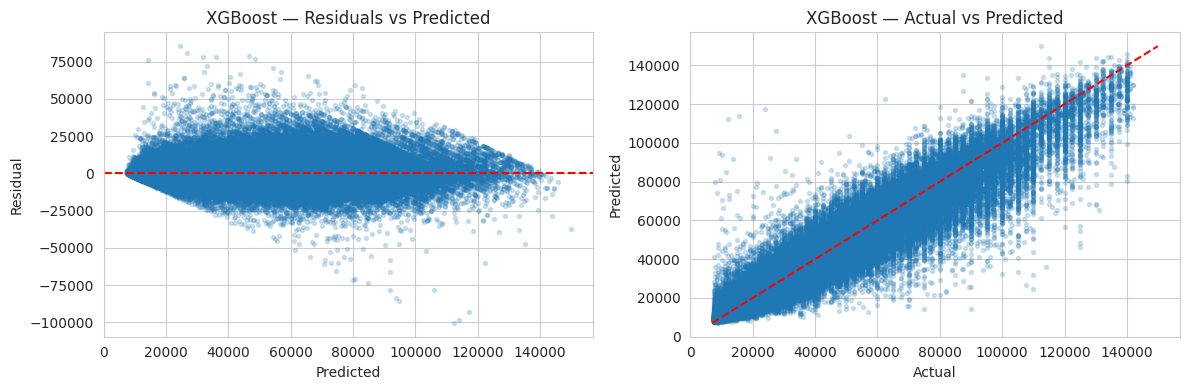

Mean absolute residual: $5,309
Median relative error: 10.5%


In [13]:
best_name = min(results, key=results.get)
best_oof = oof_preds[best_name]
residuals = y - best_oof
rel_error = np.abs(residuals) / y

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(best_oof, residuals, alpha=0.2, s=8)
axes[0].axhline(0, color='red', ls='--')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Residual')
axes[0].set_title(f'{best_name} — Residuals vs Predicted')
axes[1].scatter(y, best_oof, alpha=0.2, s=8)
mn, mx = min(y.min(), best_oof.min()), max(y.max(), best_oof.max())
axes[1].plot([mn, mx], [mn, mx], 'r--')
axes[1].set_xlabel('Actual'); axes[1].set_ylabel('Predicted')
axes[1].set_title(f'{best_name} — Actual vs Predicted')
plt.tight_layout()
plt.show()

print(f'Mean absolute residual: ${np.mean(np.abs(residuals)):,.0f}')
print(f'Median relative error: {np.median(rel_error)*100:.1f}%')


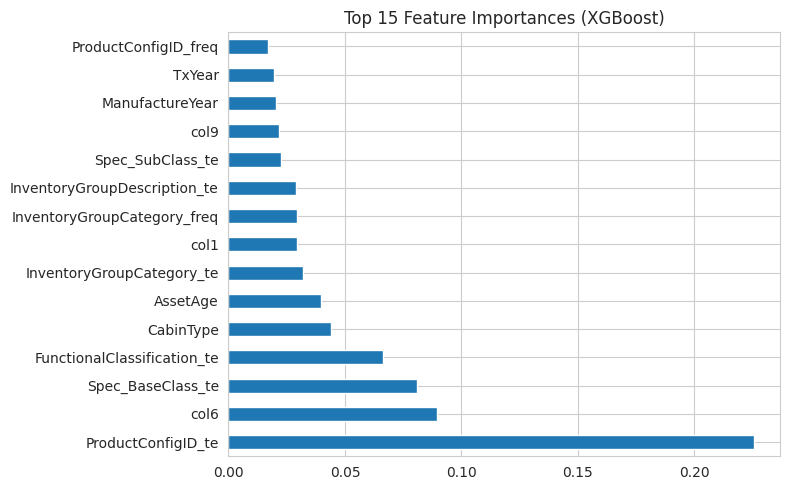

In [14]:
if best_name in ('LightGBM', 'XGBoost'):
    best_model_tmp = make_model(best_name)
    best_model_tmp.fit(X, np.log1p(y))
    imp = pd.Series(best_model_tmp.feature_importances_, index=X.columns)
    imp.sort_values(ascending=False).head(15).plot(
        kind='barh', figsize=(8, 5), title=f'Top 15 Feature Importances ({best_name})'
    )
    plt.tight_layout()
    plt.show()


In [15]:
if USE_FULL_DATA:
    train_full = pd.read_csv(TRAIN_PATH)
else:
    train_full = train

test_full = pd.read_csv(TEST_PATH)

X_full, final_artifacts = fit_transform_features(train_full)
y_full = train_full['TargetValue'].values
X_test = transform_test(test_full, final_artifacts)

for c in X_full.columns:
    if c not in X_test.columns:
        X_test[c] = 0
X_test = X_test[X_full.columns]

best_model = make_model(best_name)
best_model.fit(X_full, np.log1p(y_full))

pred_test = np.expm1(best_model.predict(X_test))
pred_test = np.clip(pred_test, 0, None)

submission = pd.DataFrame({
    'TransactionID': ss['TransactionID'],
    'TargetValue': pred_test
})

submission.to_csv('submission.csv', index=False)
print(f'Submission saved: submission.csv ({len(submission)} rows)')
submission.head()


Submission saved: submission.csv (15000 rows)


,TransactionID,TargetValue
0,1139307,68049.085938
1,1139419,77286.250000
2,1139482,29667.837891
3,1139522,20189.330078
4,1139684,12199.009766


In [16]:
import sys
sys.exit()

SystemExit: 

# Milestone 1

**Question 1 (MCQ):** Dataset Dimensions 

In [ ]:
print("Train dataset rows:", train.shape[0])
print("Test dataset rows:", test.shape[0])

**Question 2 (MCQ):** Target Variable Identification 

In [ ]:
set(train.columns) - set(test.columns)

**Question 3 (Numeric):** Feature Data Types

In [ ]:
print(train.select_dtypes(include='number').shape[1])

**Question 4 (MSQ):** Extremely Sparse Columns 

In [ ]:
missing_pct = train.isnull().mean() * 100

sparse_cols = missing_pct[missing_pct > 90]

print(f"Number of columns with >90% missing values: {len(sparse_cols)}")
print(sparse_cols.sort_values(ascending=False))

**Question 5 (Numeric):** Missing Operational Metrics 

In [ ]:
missing_count = train['OperationalHoursMeter'].isna().sum()
total_rows = len(train)

missing_pct = (missing_count / total_rows) * 100

print("Missing values:", missing_count)
print("Percentage missing:", round(missing_pct, 2), "%")

**Question 6 (MCQ):** Target Value Distribution 

In [ ]:
median_price = train['TargetValue'].median()
print(f"Median TargetValue: {median_price:,.0f}")

**Question 7 (Numeric):** Manufacture Year Anomaly

In [ ]:
train['ManufactureYear'].mode()

**Question 8 (MCQ):** Time Span of Transactions 

In [ ]:
train['TransactionDate'] = pd.to_datetime(train['TransactionDate'])

print(train['TransactionDate'].min())

**Question 9 (Numeric):** High Cardinality Identification

In [ ]:
train['Spec_BaseClass'].nunique()

**Question 10 (MCQ):** Geographical Volume 

In [ ]:
train['RegionCode'].value_counts()

**Question 11 (Numeric):** Regional Pricing Insights 

In [ ]:
train[train['RegionCode'] == 'Florida']['TargetValue'].mean()

**Question 12 (MCQ):** Asset Utilization 

In [ ]:
train['UtilizationTier'].value_counts()

**Question 13 (MCQ):** Operational Correlation

In [ ]:
train[['TargetValue', 'OperationalHoursMeter']].corr(method='pearson')

**Question 14 (MCQ):** Primary Equipment Types

In [ ]:
train['FunctionalClassification'].mode()[0]

# Milestone 2

**Question 1**

In [ ]:
train["TransactionDate"] = pd.to_datetime(train["TransactionDate"])

In [ ]:
train["TransactionYear"] = train["TransactionDate"].dt.year
train["TransactionQuarter"] = train["TransactionDate"].dt.quarter

In [ ]:
train["AssetAge"] = train["TransactionYear"] - train["ManufactureYear"]

In [ ]:
train["DescriptorLength"] = (
    train["Spec_FullDescriptor"]
    .fillna("")
    .astype(str)
    .str.len()
)

In [ ]:
train["HasOperationalHours"] = train["OperationalHoursMeter"].notna().astype(int)
train["HasVariantModifier"] = train["Spec_VariantModifier"].notna().astype(int)

In [ ]:
most_frequent_asset_age = train["AssetAge"].mode()[0]
print("Most frequent AssetAge:", most_frequent_asset_age)

**Question 2**

In [ ]:
quarter_avg = train.groupby("TransactionQuarter")["TargetValue"].mean()
print("Average TargetValue by Quarter:")
print(quarter_avg.idxmax())

**Question 3**

In [ ]:
print("Maximum DescriptorLength:", train["DescriptorLength"].max())

**Question 4**

In [ ]:
count_operational = train["HasOperationalHours"].sum()
print("HasOperationalHours = 1:", count_operational)

**Question 5**

In [ ]:
variant_percent = train["HasVariantModifier"].mean() * 100
print("Percentage with Variant Info: {:.2f}%".format(variant_percent))

**Question 6**

In [ ]:
mean_year = train["ManufactureYear"].mean()
print("Mean ManufactureYear: {:.2f}".format(mean_year))

**Question 7**

In [ ]:
encoded = pd.get_dummies(
    train,
    columns=["RegionCode", "CabinType", "UtilizationTier"],
    drop_first=True
)

region_cols = pd.get_dummies(train["RegionCode"], drop_first=True).shape[1]
cabin_cols = pd.get_dummies(train["CabinType"], drop_first=True).shape[1]
util_cols = pd.get_dummies(train["UtilizationTier"], drop_first=True).shape[1]

total_encoded = region_cols + cabin_cols + util_cols

In [ ]:
print("Encoded Columns Created:", total_encoded)

**Question 8**

In [ ]:
numeric_cols = train.select_dtypes(include=np.number)
corr = numeric_cols.corr(method="pearson")
target_corr = corr["TargetValue"].abs().sort_values(ascending=False)

In [ ]:
print(target_corr)

**Question 9**

In [ ]:
features = ["ManufactureYear", "OperationalHoursMeter", "AssetAge"]

X = train[features].copy()
y = train["TargetValue"]

In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
print("Training Shape:", X_train.shape)

**Question 10**

In [ ]:
print("Validation Shape:", X_valid.shape)

**Question 11**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X2 = train[["ManufactureYear", "AssetAge"]]

X2 = SimpleImputer(strategy="mean").fit_transform(X2)
X2 = StandardScaler().fit_transform(X2)

X_train2, X_valid2, y_train2, y_valid2 = train_test_split(
    X2,
    y,
    test_size=0.20,
    random_state=42
)

model = LinearRegression()
model.fit(X_train2, y_train2)

pred = model.predict(X_valid2)

r2 = r2_score(y_valid2, pred)

print("R2 Score:", r2)

# Milestone 3

**Question 1**

In [ ]:
train_df = train.copy()

In [ ]:
train_df["TransactionDate"] = pd.to_datetime(train_df["TransactionDate"])

train_df["SaleYear"] = train_df["TransactionDate"].dt.year

mode_sale_year = train_df["SaleYear"].mode()[0]

print(mode_sale_year)

**Question 2**

In [ ]:
train_df["ManufactureYear"] = train_df["ManufactureYear"].replace([1000, 1001], np.nan)

train_df["AssetAge"] = train_df["SaleYear"] - train_df["ManufactureYear"]

median_age = train_df["AssetAge"].median()

print(median_age)

**Question 3**

In [ ]:
missing_fraction = train_df.isna().mean()

cols_to_drop = missing_fraction[missing_fraction > 0.80]

print("Columns to drop:", len(cols_to_drop))
print(cols_to_drop.index.tolist())

**Question 4**

Median

**Question 5**

In [ ]:
filled = train_df["CabinType"].fillna("Missing")

missing_count = (filled == "Missing").sum()

print(missing_count)

**Question 6**

In [ ]:
train_df["HoursPerYear"] = (
    train_df["OperationalHoursMeter"] /
    train_df["AssetAge"]
)

train_df["HoursPerYear"] = train_df["HoursPerYear"].replace([np.inf, -np.inf], np.nan)

median_hours = train_df["HoursPerYear"].median()

print(median_hours)

**Question 7**

The categorical feature has very high cardinality

**Question 8**

In [ ]:
from sklearn.model_selection import train_test_split

df = train.copy()

X = df.drop(columns=["TargetValue"])
y = df["TargetValue"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape[0])

**Question 9**

In [ ]:
import numpy as np

df = train.copy()

y_log = np.log1p(df["TargetValue"])

print(y_log.std())

**Question 10**

Before applying any scalers, target encoders, or median imputations.

**Question 11**

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

df = train.copy()

enc = OrdinalEncoder()

encoded = enc.fit_transform(df[["UtilizationTier"]])

print(len(enc.categories_[0]))

**Question 12**

Gradient Boosted Trees (LightGBM/XGBoost)

**Question 13**

The total number of individual decision trees built in the ensemble.

**Question 14**

The model used that specific feature frequently to make highly accurate splits in the decision trees, meaning it strongly influences the target prediction.

**Question 15**

It automatically halts training if the validation score stops improving, preventing the model from overfitting to the training data.